# Stage 3 · Step 05 — Feature-space visualisation

For a readable subset of classes, visualise the original
features $z$ and the transported features $\hat z$ for **both** Stage 3 methods, using the same
test examples and the same class colours throughout, with the embedding computed **jointly**
over the sets being compared.

Steps 02 and 03 saved every run's metrics and curves but not the flow weights, so this step
retrains the six models it needs — seed 0, at the configurations step 04 selected on
validation accuracy — and saves them, so nothing downstream has to retrain again.

## 1 · Setup

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.decomposition import PCA

from cvlab.data import make_kshot_subset
from cvlab.features import load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab3 import COMBOS, K_SHOT, SEEDS, T_STEPS, FrozenClassifier, transform
from cvlab3.guided import GuidedConfig, train_classifier_guided
from cvlab3.paths import RESULTS_ROOT, step_dirs
from cvlab3.training import EndToEndConfig, train_end_to_end

apply_style()
PLOTS, TABLES = step_dirs("05_visualizations")
art = ArtifactWriter(PLOTS, TABLES)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

setup = torch.load(RESULTS_ROOT / "frozen_classifiers.pt", map_location="cpu", weights_only=False)

VIZ_SEED = 0
N_CLASSES_SHOWN = 6                 # matching Stage 2's visualisation convention
PALETTE = plt.cm.tab10(np.linspace(0, 1, 10))

COMBO_LABEL = {("resnet18", "DTD"): "ResNet-18 / DTD",
               ("dinov2", "FGVC-Aircraft"): "DINOv2 / Aircraft",
               ("resnet18", "FGVC-Aircraft"): "ResNet-18 / Aircraft"}

# The configurations step 04 selected, on validation accuracy.
S1_CONFIG = EndToEndConfig(lr=1e-4)
S2_CONFIG = GuidedConfig(refresh_every=10)
print(f"Strategy 1: lr={S1_CONFIG.lr:g}   Strategy 2: refresh_every={S2_CONFIG.refresh_every}")
print(f"Visualising seed {VIZ_SEED}, {N_CLASSES_SHOWN} classes, T = {T_STEPS}")

Strategy 1: lr=0.0001   Strategy 2: refresh_every=10
Visualising seed 0, 6 classes, T = 4


In [2]:
import time

models, rows = {}, []
t0 = time.perf_counter()
for encoder, dataset in COMBOS:
    key = f"{encoder}__{dataset}__K{K_SHOT}__seed{VIZ_SEED}"
    payload = setup["classifiers"][key]
    clf = FrozenClassifier.from_state_dict(payload["state_dict"]).to(DEVICE)

    tr = load_features(encoder, dataset, "train")
    va = load_features(encoder, dataset, "val")
    te = load_features(encoder, dataset, "test")
    x, y = make_kshot_subset(tr.features, tr.labels, K_SHOT, VIZ_SEED)

    args = dict(net_dim=payload["dim"], clf=clf, train_x=x, train_y=y,
                val_x=va.features, val_y=va.labels, test_x=te.features, test_y=te.labels,
                seed=VIZ_SEED, baseline_acc=payload["stage1_test_acc"], T=T_STEPS,
                device=DEVICE)

    r1 = train_end_to_end(config=S1_CONFIG, **args)
    r2 = train_classifier_guided(config=S2_CONFIG, **args)
    models[(encoder, dataset)] = {"clf": clf, "s1": r1, "s2": r2, "payload": payload}
    rows.append({"encoder": encoder, "dataset": dataset,
                 "probe": payload["stage1_test_acc"] * 100,
                 "s1": r1.test_acc * 100, "s1_delta": r1.delta_pp,
                 "s2": r2.test_acc * 100, "s2_delta": r2.delta_pp})

retrained = pd.DataFrame(rows)
art.table(retrained, "visualised_models")
print(f"6 models retrained in {time.perf_counter() - t0:.0f}s\n")
print(retrained.round(2).to_string(index=False))

  saved table -> tables/visualised_models.csv  (3 rows)
6 models retrained in 81s

 encoder       dataset  probe    s1  s1_delta    s2  s2_delta
resnet18           DTD  51.17 51.06     -0.11 51.91      0.74
  dinov2 FGVC-Aircraft  53.20 54.58      1.38 54.52      1.32
resnet18 FGVC-Aircraft  26.70 28.98      2.28 29.67      2.97


In [3]:
# Save the weights, so this is the last time any of them has to be retrained.
torch.save(
    {f"{e}__{d}": {"strategy1": m["s1"].state_dict, "strategy2": m["s2"].state_dict,
                   "dim": m["payload"]["dim"], "seed": VIZ_SEED,
                   "s1_config": S1_CONFIG.as_dict(), "s2_config": S2_CONFIG.as_dict()}
     for (e, d), m in models.items()},
    RESULTS_ROOT / "visualised_flow_weights.pt")
print(f"saved -> {RESULTS_ROOT / 'visualised_flow_weights.pt'} "
      f"({(RESULTS_ROOT / 'visualised_flow_weights.pt').stat().st_size/1024:.0f} KB)")

saved -> C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_3\results\visualised_flow_weights.pt (17467 KB)


## 2 · Building the comparison

Three feature sets per combination — the original $z$, Strategy 1's $\hat z$, and Strategy 2's
$\hat z$ — all on the **same test images**.

**PCA rather than t-SNE.** PCA is used for the same reason Stage 1
gave: it is deterministic (no perplexity or seed to justify), and "compute the embedding
jointly over the sets being compared" has an unambiguous meaning for a linear method — one
projection is fitted on the concatenation of all three sets and applied to each, so the panels
are directly comparable rather than three independent rotations.

**Classes are chosen by an even stride** through the sorted class list, not hand-picked.

In [4]:
def build_views(encoder, dataset):
    m = models[(encoder, dataset)]
    te = load_features(encoder, dataset, "test")
    labels_all = te.labels.numpy()

    # Even stride through the sorted class list - not hand-picked.
    classes = np.linspace(0, len(te.classes) - 1, N_CLASSES_SHOWN).astype(int)
    mask = np.isin(labels_all, classes)
    x = te.features[mask].to(DEVICE)
    y = labels_all[mask]

    nets = {"Strategy 1": m["s1"], "Strategy 2": m["s2"]}
    views = {"Original $z$": x.cpu().numpy()}
    for name, res in nets.items():
        from cvlabfm.flow import VelocityNet
        net = VelocityNet(m["payload"]["dim"], hidden_dim=512, n_hidden=2).to(DEVICE)
        net.load_state_dict({k: v.to(DEVICE) for k, v in res.state_dict.items()})
        net.eval()
        with torch.no_grad():
            views[f"{name} $\\hat z$"] = transform(net, x, T_STEPS).cpu().numpy()
    return views, y, classes, [te.classes[c] for c in classes], x


def joint_pca(views):
    # One projection fitted on the concatenation of every set being compared.
    stacked = np.concatenate(list(views.values()), axis=0)
    pca = PCA(n_components=2, random_state=0).fit(stacked)
    return {k: pca.transform(v) for k, v in views.items()}, pca


VIEWS = {}
for encoder, dataset in COMBOS:
    v, y, cls, names, x = build_views(encoder, dataset)
    proj, pca = joint_pca(v)
    VIEWS[(encoder, dataset)] = dict(views=v, proj=proj, y=y, classes=cls,
                                     class_names=names, x=x, pca=pca)
    print(f"{COMBO_LABEL[(encoder, dataset)]:<22} {len(y):>5} test images, "
          f"{N_CLASSES_SHOWN} classes, joint PCA explains "
          f"{pca.explained_variance_ratio_.sum()*100:.1f}% of variance")

ResNet-18 / DTD          240 test images, 6 classes, joint PCA explains 21.7% of variance
DINOv2 / Aircraft        199 test images, 6 classes, joint PCA explains 33.8% of variance
ResNet-18 / Aircraft     199 test images, 6 classes, joint PCA explains 20.7% of variance


## 3 · The required figure

Same test images, same class colours, one jointly-fitted projection per row.

  saved plot  -> plots/feature_space_resnet18_dtd.png


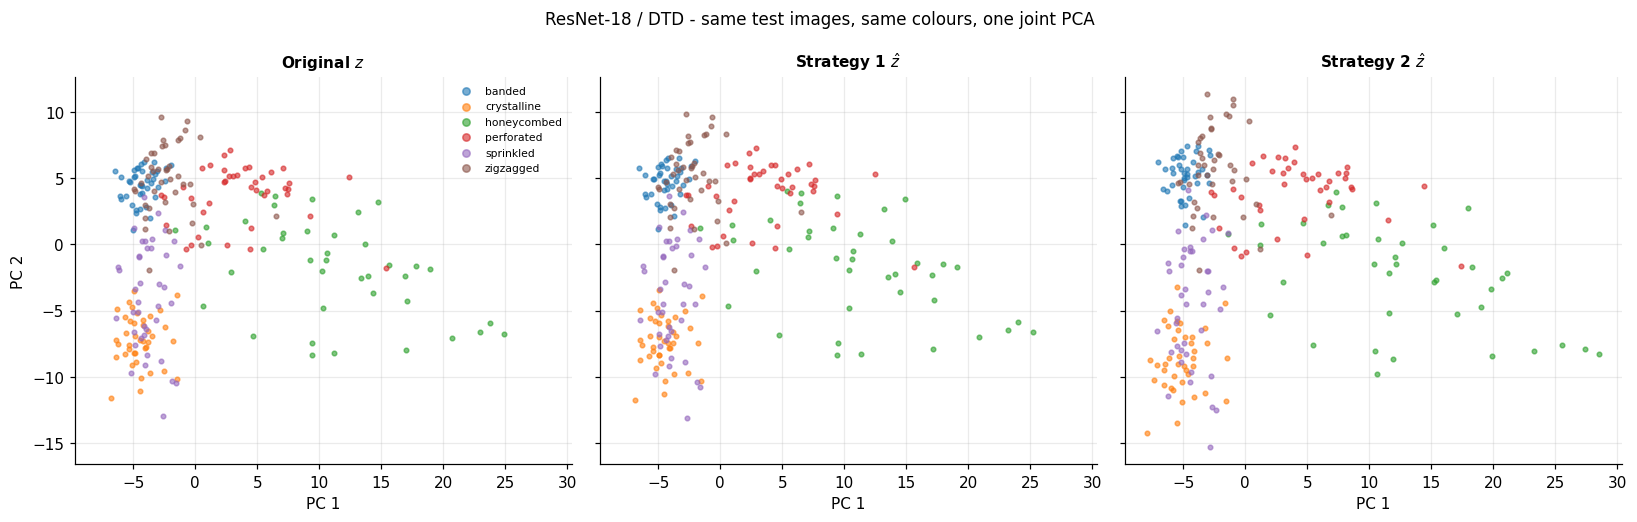

  saved plot  -> plots/feature_space_dinov2_fgvcaircraft.png


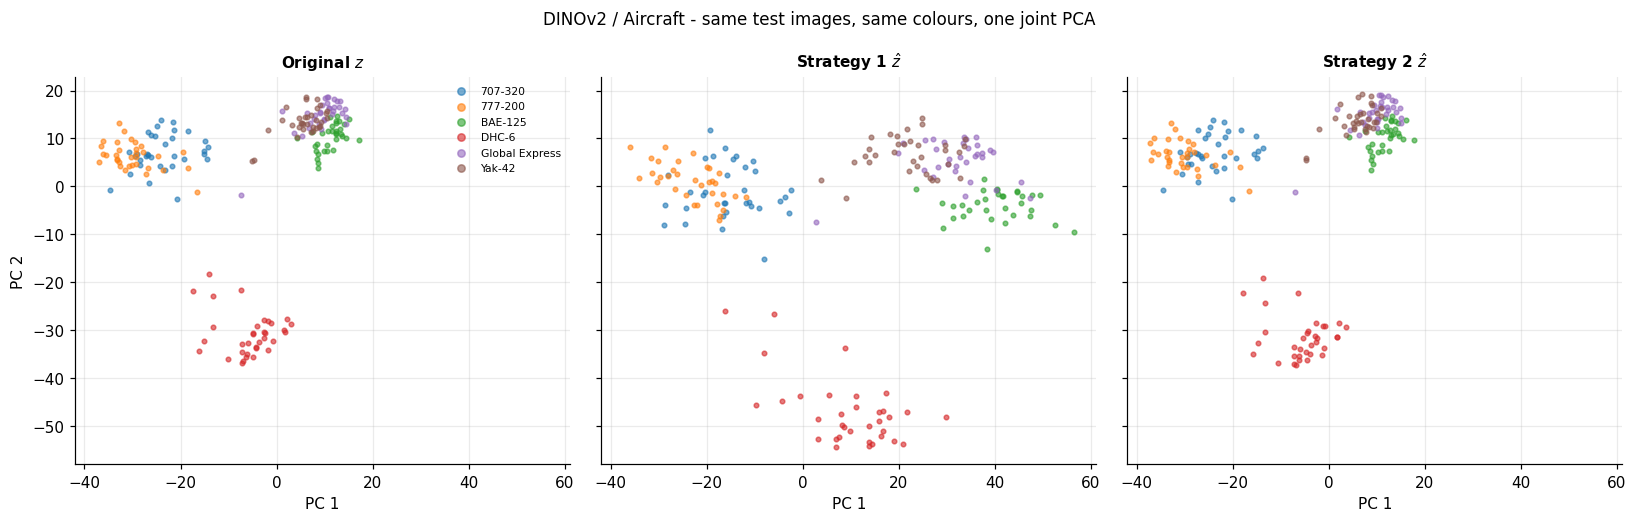

  saved plot  -> plots/feature_space_resnet18_fgvcaircraft.png


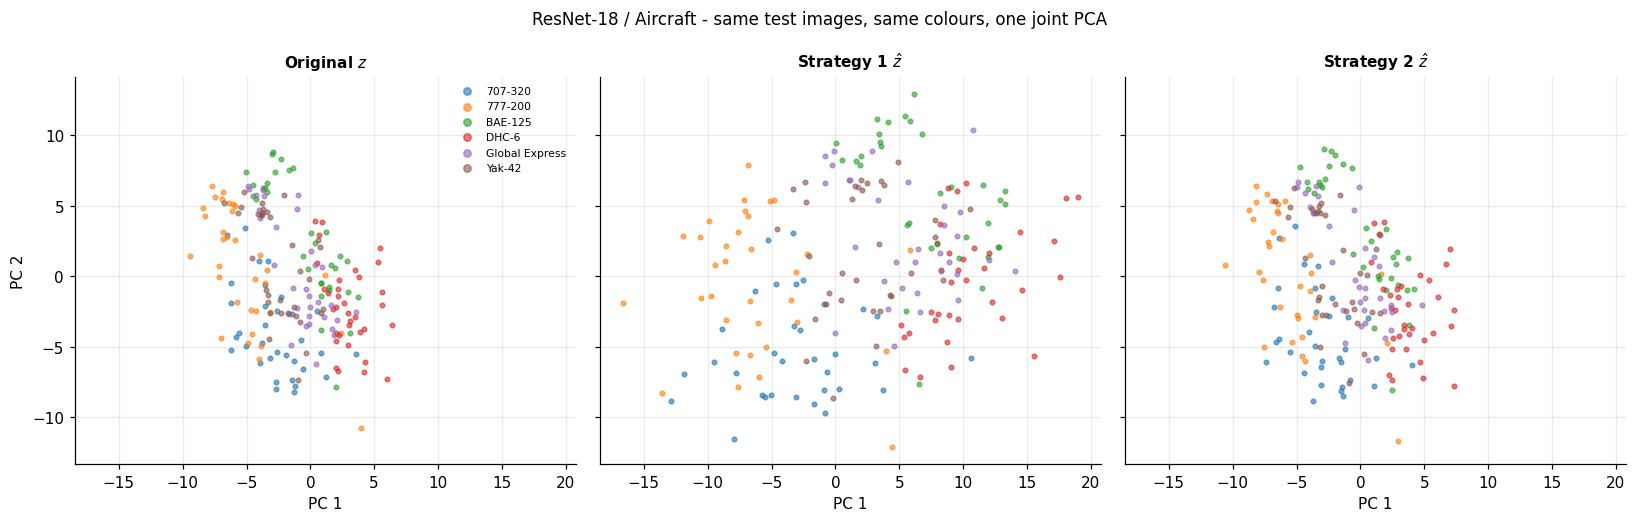

In [5]:
for encoder, dataset in COMBOS:
    V = VIEWS[(encoder, dataset)]
    panels = list(V["proj"].keys())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

    for ax, panel in zip(axes, panels):
        P = V["proj"][panel]
        for i, c in enumerate(V["classes"]):
            sel = V["y"] == c
            ax.scatter(P[sel, 0], P[sel, 1], s=9, alpha=0.6, color=PALETTE[i],
                       label=V["class_names"][i] if panel == panels[0] else None)
        ax.set_title(panel, fontsize=10)
        ax.set_xlabel("PC 1")
    axes[0].set_ylabel("PC 2")
    axes[0].legend(fontsize=7, markerscale=1.6, loc="best")

    fig.suptitle(f"{COMBO_LABEL[(encoder, dataset)]} - same test images, same colours, "
                 f"one joint PCA", fontsize=11)
    fig.tight_layout()
    art.figure(fig, f"feature_space_{encoder}_{dataset.replace('-', '').lower()}")
    plt.show()

## 4 · What actually changed

The pictures show the flow moving features, but a 2-D projection cannot say whether the
*class structure* improved. Three quantities measured in the full feature space can.

**Logit margin** is the one that matters most here. The classifier is linear and frozen, so
its decision is entirely determined by the gap between the top logit and the runner-up. Stage 3
can only help by widening that gap on examples it gets right — or by flipping ones it gets
wrong.

In [6]:
criterion = nn.CrossEntropyLoss()
rows = []
for encoder, dataset in COMBOS:
    V = VIEWS[(encoder, dataset)]
    m = models[(encoder, dataset)]
    te = load_features(encoder, dataset, "test")
    y_t = torch.tensor(V["y"], device=DEVICE)

    for panel, feats in V["views"].items():
        f = torch.tensor(feats, device=DEVICE)
        with torch.no_grad():
            logits = m["clf"](f)
            top2 = logits.topk(2, dim=1).values
            margin = (top2[:, 0] - top2[:, 1])
            correct = logits.argmax(1) == y_t

            # class separability in the full space, the Stage 1 step-02 measure
            fn = torch.nn.functional.normalize(f, dim=1)
            cents = torch.stack([fn[y_t == c].mean(0) for c in V["classes"]])
            cents = torch.nn.functional.normalize(cents, dim=1)
            sims = fn @ cents.T
            own = sims[torch.arange(len(y_t)),
                       torch.tensor([list(V["classes"]).index(int(v)) for v in V["y"]],
                                    device=DEVICE)]
            other = (sims.sum(1) - own) / (len(V["classes"]) - 1)

        rows.append({
            "encoder": encoder, "dataset": dataset, "panel": panel,
            "accuracy": correct.float().mean().item() * 100,
            "logit_margin": margin.mean().item(),
            "margin_correct": margin[correct].mean().item(),
            "displacement": float(np.linalg.norm(feats - V["views"]["Original $z$"], axis=1).mean()),
            "own_sim": own.mean().item(), "other_sim": other.mean().item(),
            "separability": (own - other).mean().item(),
        })

geom = pd.DataFrame(rows)
art.table(geom, "feature_geometry")

for (e, d), g in geom.groupby(["encoder", "dataset"], sort=False):
    print(f"\n{COMBO_LABEL[(e, d)]}")
    print(f"  {'panel':<22} {'acc':>7} {'margin':>9} {'separability':>13} {'moved':>8}")
    for _, r in g.iterrows():
        print(f"  {r['panel']:<22} {r['accuracy']:6.2f}% {r['logit_margin']:9.3f} "
              f"{r['separability']:13.4f} {r['displacement']:8.2f}")
geom

  saved table -> tables/feature_geometry.csv  (9 rows)

ResNet-18 / DTD
  panel                      acc    margin  separability    moved
  Original $z$            65.83%     1.320        0.1936     0.00
  Strategy 1 $\hat z$     64.58%     1.317        0.1982     0.54
  Strategy 2 $\hat z$     65.42%     2.533        0.2381     4.46

DINOv2 / Aircraft
  panel                      acc    margin  separability    moved
  Original $z$            53.27%     2.396        0.4139     0.00
  Strategy 1 $\hat z$     54.27%     3.785        0.3400    34.94
  Strategy 2 $\hat z$     54.77%     3.920        0.4198     4.60

ResNet-18 / Aircraft
  panel                      acc    margin  separability    moved
  Original $z$            23.12%     1.277        0.0364     0.00
  Strategy 1 $\hat z$     25.13%     1.856        0.0793     9.81
  Strategy 2 $\hat z$     26.63%     2.072        0.0467     3.22


,encoder,dataset,panel,accuracy,logit_margin,margin_correct,displacement,own_sim,other_sim,separability
0,resnet18,DTD,Original $z$,65.833336,1.320469,1.658297,0.000000,0.768743,0.575177,0.193566
1,resnet18,DTD,Strategy 1 $\hat z$,64.583337,1.316890,1.674129,0.538618,0.768145,0.569950,0.198195
2,resnet18,DTD,Strategy 2 $\hat z$,65.416670,2.532612,3.280975,4.455558,0.755646,0.517589,0.238056
3,dinov2,FGVC-Aircraft,Original $z$,53.266329,2.396253,3.259398,0.000000,0.744658,0.330744,0.413913
4,dinov2,FGVC-Aircraft,Strategy 1 $\hat z$,54.271358,3.785221,5.160655,34.939060,0.817483,0.477498,0.339985
5,dinov2,FGVC-Aircraft,Strategy 2 $\hat z$,54.773867,3.920261,5.497384,4.602199,0.740492,0.320697,0.419795
6,resnet18,FGVC-Aircraft,Original $z$,23.115578,1.276635,2.460931,0.000000,0.899950,0.863581,0.036369
7,resnet18,FGVC-Aircraft,Strategy 1 $\hat z$,25.125629,1.856399,3.179376,9.814490,0.898490,0.819180,0.079310
8,resnet18,FGVC-Aircraft,Strategy 2 $\hat z$,26.633164,2.071652,4.111771,3.222938,0.884332,0.837662,0.046670


In [7]:
# Did the flow widen the margin, and did separability move with it?
summary = []
for (e, d), g in geom.groupby(["encoder", "dataset"], sort=False):
    base = g[g.panel == "Original $z$"].iloc[0]
    for panel in [p for p in g.panel if p != "Original $z$"]:
        r = g[g.panel == panel].iloc[0]
        summary.append({
            "encoder": e, "dataset": d, "strategy": panel.split(" $")[0],
            "d_accuracy_pp": r["accuracy"] - base["accuracy"],
            "margin_ratio": r["logit_margin"] / base["logit_margin"],
            "d_separability": r["separability"] - base["separability"],
        })
chg = pd.DataFrame(summary)
art.table(chg, "geometry_change")

print("Change against the original features, on the same test images:\n")
print(f"  {'combination':<22} {'strategy':<12} {'d acc':>8} {'margin x':>10} {'d separability':>16}")
print("  " + "-" * 72)
for _, r in chg.iterrows():
    print(f"  {COMBO_LABEL[(r['encoder'], r['dataset'])]:<22} {r['strategy']:<12} "
          f"{r['d_accuracy_pp']:+7.2f} {r['margin_ratio']:10.2f} {r['d_separability']:+16.4f}")
chg

  saved table -> tables/geometry_change.csv  (6 rows)
Change against the original features, on the same test images:

  combination            strategy        d acc   margin x   d separability
  ------------------------------------------------------------------------
  ResNet-18 / DTD        Strategy 1     -1.25       1.00          +0.0046
  ResNet-18 / DTD        Strategy 2     -0.42       1.92          +0.0445
  DINOv2 / Aircraft      Strategy 1     +1.01       1.58          -0.0739
  DINOv2 / Aircraft      Strategy 2     +1.51       1.64          +0.0059
  ResNet-18 / Aircraft   Strategy 1     +2.01       1.45          +0.0429
  ResNet-18 / Aircraft   Strategy 2     +3.52       1.62          +0.0103


,encoder,dataset,strategy,d_accuracy_pp,margin_ratio,d_separability
0,resnet18,DTD,Strategy 1,-1.249999,0.997289,0.004629
1,resnet18,DTD,Strategy 2,-0.416666,1.917964,0.044490
2,dinov2,FGVC-Aircraft,Strategy 1,1.005030,1.579642,-0.073929
3,dinov2,FGVC-Aircraft,Strategy 2,1.507539,1.635996,0.005882
4,resnet18,FGVC-Aircraft,Strategy 1,2.010050,1.454134,0.042941
5,resnet18,FGVC-Aircraft,Strategy 2,3.517586,1.622745,0.010301


  saved plot  -> plots/what_the_flow_changes.png


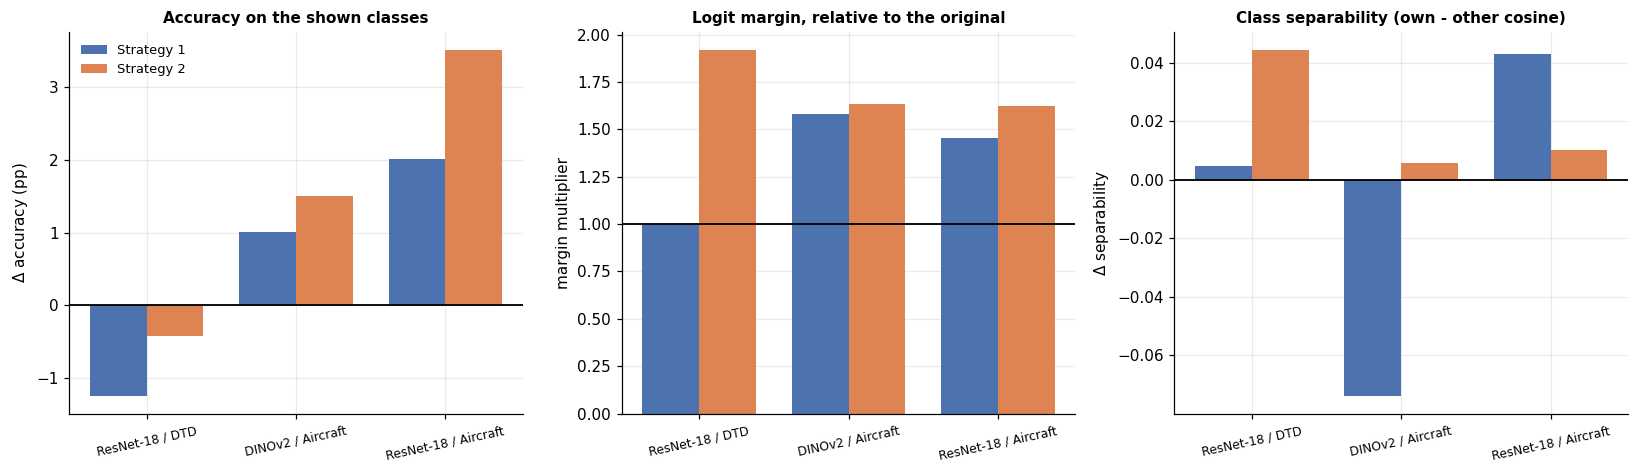

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
xs = np.arange(len(COMBOS))
labels = [COMBO_LABEL[c] for c in COMBOS]

def series(col, strategy):
    return [chg[(chg.encoder == e) & (chg.dataset == d)
                & (chg.strategy == strategy)][col].iloc[0] for e, d in COMBOS]

for ax, (col, title, ylab) in zip(axes, [
        ("d_accuracy_pp", "Accuracy on the shown classes", r"$\Delta$ accuracy (pp)"),
        ("margin_ratio", "Logit margin, relative to the original", "margin multiplier"),
        ("d_separability", "Class separability (own - other cosine)", r"$\Delta$ separability")]):
    ax.bar(xs - 0.19, series(col, "Strategy 1"), 0.38, color="#4C72B0", label="Strategy 1")
    ax.bar(xs + 0.19, series(col, "Strategy 2"), 0.38, color="#DD8452", label="Strategy 2")
    ax.axhline(1.0 if col == "margin_ratio" else 0.0, color="black", lw=1.2)
    ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8, rotation=12)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylab)
axes[0].legend(fontsize=8.5)
fig.tight_layout()
art.figure(fig, "what_the_flow_changes")
plt.show()

## 5 · Saving

In [9]:
art.manifest()
print()
print("Step 05 complete.\n")
print(f"  {len(COMBOS)} combinations visualised, {N_CLASSES_SHOWN} classes each, "
      f"seed {VIZ_SEED}, joint PCA")
print(f"  flow weights saved to results/visualised_flow_weights.pt")
mr = chg["margin_ratio"]
print(f"  logit margin multiplier : {mr.min():.2f}x to {mr.max():.2f}x")
ds = chg["d_separability"]
print(f"  change in separability  : {ds.min():+.4f} to {ds.max():+.4f}")
print("\nNext: step 06, which unfreezes the classifier.")

7 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_3\Work\05_visualizations

Step 05 complete.

  3 combinations visualised, 6 classes each, seed 0, joint PCA
  flow weights saved to results/visualised_flow_weights.pt
  logit margin multiplier : 1.00x to 1.92x
  change in separability  : -0.0739 to +0.0445

Next: step 06, which unfreezes the classifier.
